# Satellite image generation (AWS data)

**Libraries needed:**

In [1]:
#---Cloud search libraries
import s3fs
import requests
import fnmatch

#---Accessory libraries
import datetime
import xarray as xr
import netCDF4
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as feature

**Set the datetime and band to view:**

In [2]:
year = 2025
month = 6
day = 25
hour = 6
ten_minutes = 0

band = '14' #---Include the leading zero, if needed

julian_day = datetime.datetime(year, month, day).strftime('%j')
print(julian_day)

datetime_str = str(year)+'-'+str(month).zfill(2)+'-'+str(day).zfill(2)+' '+str(hour).zfill(2)+'Z'
print(datetime_str)

176
2025-06-25 06Z


**Select region for visualization:**

In [3]:
#--- Extent
latitude_north = 61
latitude_south = 30
longitude_west = -80
longitude_east = -25

#--- Georges Bank (zoomed in)
# latitude_north = 42.5
# latitude_south = 37
# longitude_west = -71.5
# longitude_east = -64

#--- Georges Bank
# latitude_north = 46
# latitude_south = 33
# longitude_west = -73
# longitude_east = -57

#--- Oaxaca
# latitude_north = 24
# latitude_south = 8
# longitude_west = -109
# longitude_east = -81

#--- Oaxaca (zoomed in)
# latitude_north = 21
# latitude_south = 8
# longitude_west = -105
# longitude_east = -85

#--- Global
# latitude_north = 90
# latitude_south = -90
# longitude_west = -360
# longitude_east = 0

#--- Gulf Stream
# latitude_north = 51
# latitude_south = 30
# longitude_west = -80
# longitude_east = -55
 
#--- Somalian Coast (Eastern hemisphere difficulties)
# latitude_north = 12
# latitude_south = 0
# longitude_west = 43
# longitude_east = 60

#--- Strait of Gibraltar
# latitude_north = 38
# latitude_south = 34
# longitude_west = -8
# longitude_east = -3

#--- Colorado
# latitude_north = 41.0
# latitude_south = 37.0
# longitude_west = -109.05
# longitude_east = -102.04

**Connecting to AWS remote storage:**

In [4]:
fs = s3fs.S3FileSystem(anon=True)

**Search the AWS database:**

In [11]:
bucket = 'noaa-goes19'
product = 'ABI-L1b-RadF' #---Full disk ABI radiance

#---Add band selection here (C**)

data_path = bucket + '/' + product + '/'  + str(year) + '/' + julian_day + '/' + str(hour).zfill(2)

files = fs.ls(data_path)

files_band = [file for file in files if fnmatch.fnmatch(file.split('/')[-1], 'OR_ABI-L1b-RadF-M6C' + band + '*')]

In [12]:
file = files_band[ten_minutes] #---first is the top-of-the-hour
print(file)

noaa-goes19/ABI-L1b-RadF/2025/176/06/OR_ABI-L1b-RadF-M6C14_G19_s20251760600205_e20251760609514_c20251760609560.nc


In [13]:
resp = requests.get(f'https://'+bucket+'.s3.amazonaws.com/'+file[12:])
if str(resp) != '<Response [200]>':
    print('b07 file not found in AWS servers')

**Open the satellite data:**

In [14]:
nc = netCDF4.Dataset(file, memory = resp.content)
ds = xr.open_dataset(xr.backends.NetCDF4DataStore(nc))

**Get the latitudes and longitudes for the satellite image:**

In [15]:
def calc_latlon(ds):
    # The math for this function was taken from 
    # https://makersportal.com/blog/2018/11/25/goes-r-satellite-latitude-and-longitude-grid-projection-algorithm
    x = ds.x
    y = ds.y
    goes_imager_projection = ds.goes_imager_projection
    
    x,y = np.meshgrid(x,y)
    
    r_eq = goes_imager_projection.attrs["semi_major_axis"]
    r_pol = goes_imager_projection.attrs["semi_minor_axis"]
    l_0 = goes_imager_projection.attrs["longitude_of_projection_origin"] * (np.pi/180)
    h_sat = goes_imager_projection.attrs["perspective_point_height"]
    H = r_eq + h_sat
    
    a = np.sin(x)**2 + (np.cos(x)**2 * (np.cos(y)**2 + (r_eq**2 / r_pol**2) * np.sin(y)**2))
    b = -2 * H * np.cos(x) * np.cos(y)
    c = H**2 - r_eq**2
    
    #--- Added absolute to remove error
    r_s = (-b - np.sqrt(np.absolute(b**2 - 4*a*c)))/(2*a)
    
    s_x = r_s * np.cos(x) * np.cos(y)
    s_y = -r_s * np.sin(x)
    s_z = r_s * np.cos(x) * np.sin(y)
    
    lat = np.arctan((r_eq**2 / r_pol**2) * (s_z / np.sqrt((H-s_x)**2 +s_y**2))) * (180/np.pi)
    lon = (l_0 - np.arctan(s_y / (H-s_x))) * (180/np.pi)
    
    ds = ds.assign_coords({
        "lat":(["y","x"],lat),
        "lon":(["y","x"],lon)
    })
    ds.lat.attrs["units"] = "degrees_north"
    ds.lon.attrs["units"] = "degrees_east"
    return ds



def get_xy_from_latlon(ds, lats, lons):
    lat1, lat2 = lats
    lon1, lon2 = lons

    lat = ds.lat.data
    lon = ds.lon.data
    
    x = ds.x.data
    y = ds.y.data
    
    x,y = np.meshgrid(x,y)
    
    x = x[(lat >= lat1) & (lat <= lat2) & (lon >= lon1) & (lon <= lon2)]
    y = y[(lat >= lat1) & (lat <= lat2) & (lon >= lon1) & (lon <= lon2)] 
    
    return ((min(x), max(x)), (min(y), max(y)))

In [16]:
ds_lat_lon = calc_latlon(ds)

#---This is needed to convert the lat/lon range into the x/y dimensions
#------The dataset will only filter by the official dimensions
((x1,x2), (y1, y2)) = get_xy_from_latlon(ds_lat_lon, (latitude_south, latitude_north), (longitude_west, longitude_east))

In [17]:
region = ds_lat_lon.sel(x=slice(x1, x2), y=slice(y2, y1))

In [18]:
region

<xarray.Dataset> Size: 84MB
Dimensions:                                           (y: 1249, x: 2804,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       band: 1,
                                                       number_of_harmonization_coefficients: 3,
                                                       num_star_looks: 24)
Coordinates:
    t                                                 datetime64[ns] 8B ...
  * y                                                 (y) float32 5kB 0.1518 ...
  * x                                                 (x) float32 11kB -0.013...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
    band_id                                           (band) int8 1B ...
    band_wavelength                                   (band) float32 4B ...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
    lat                                               (y, x) float64 28MB 73....
    lon                                               (y, x) float64 28MB -92...
Dimensions without coordinates: number_of_time_bounds, number_of_image_bounds,
                                band, number_of_harmonization_coefficients,
                                num_star_looks
Data variables: (12/39)
    Rad                                               (y, x) float32 14MB ...
    DQF                                               (y, x) float32 14MB ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    goes_imager_projection                            int32 4B ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    ...                                                ...
    algorithm_dynamic_input_data_container            int32 4B ...
    processing_parm_version_container                 int32 4B ...
    algorithm_product_version_container               int32 4B ...
    star_id                                           (num_star_looks) float32 96B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           RBU
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2025-06-25T06:09:56.0Z
    time_coverage_start:       2025-06-25T06:00:20.5Z
    time_coverage_end:         2025-06-25T06:09:51.4Z
    LUT_Filenames:             SpaceLookParams(FM4A_CDRL79RevA_DO_14_00_00)-7...
    id:                        6bdb7892-fb6c-4afe-8ff4-b1c98565abe6

**Convert radiance to brightness temperature:**
* Satellite data has the conversion constants in the metadata

In [19]:
wl = round(region.band_wavelength.values[0],1)

Tb = (region.planck_fk2/(np.log((region.planck_fk1/region.Rad)+1)) - region.planck_bc1)/region.planck_bc2

**Plotting single band brightness temperature:**

/var/folders/s0/p4kwg0r17s59t6f4g9btngzw0000gn/T/ipykernel_11860/1759364562.py:66: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


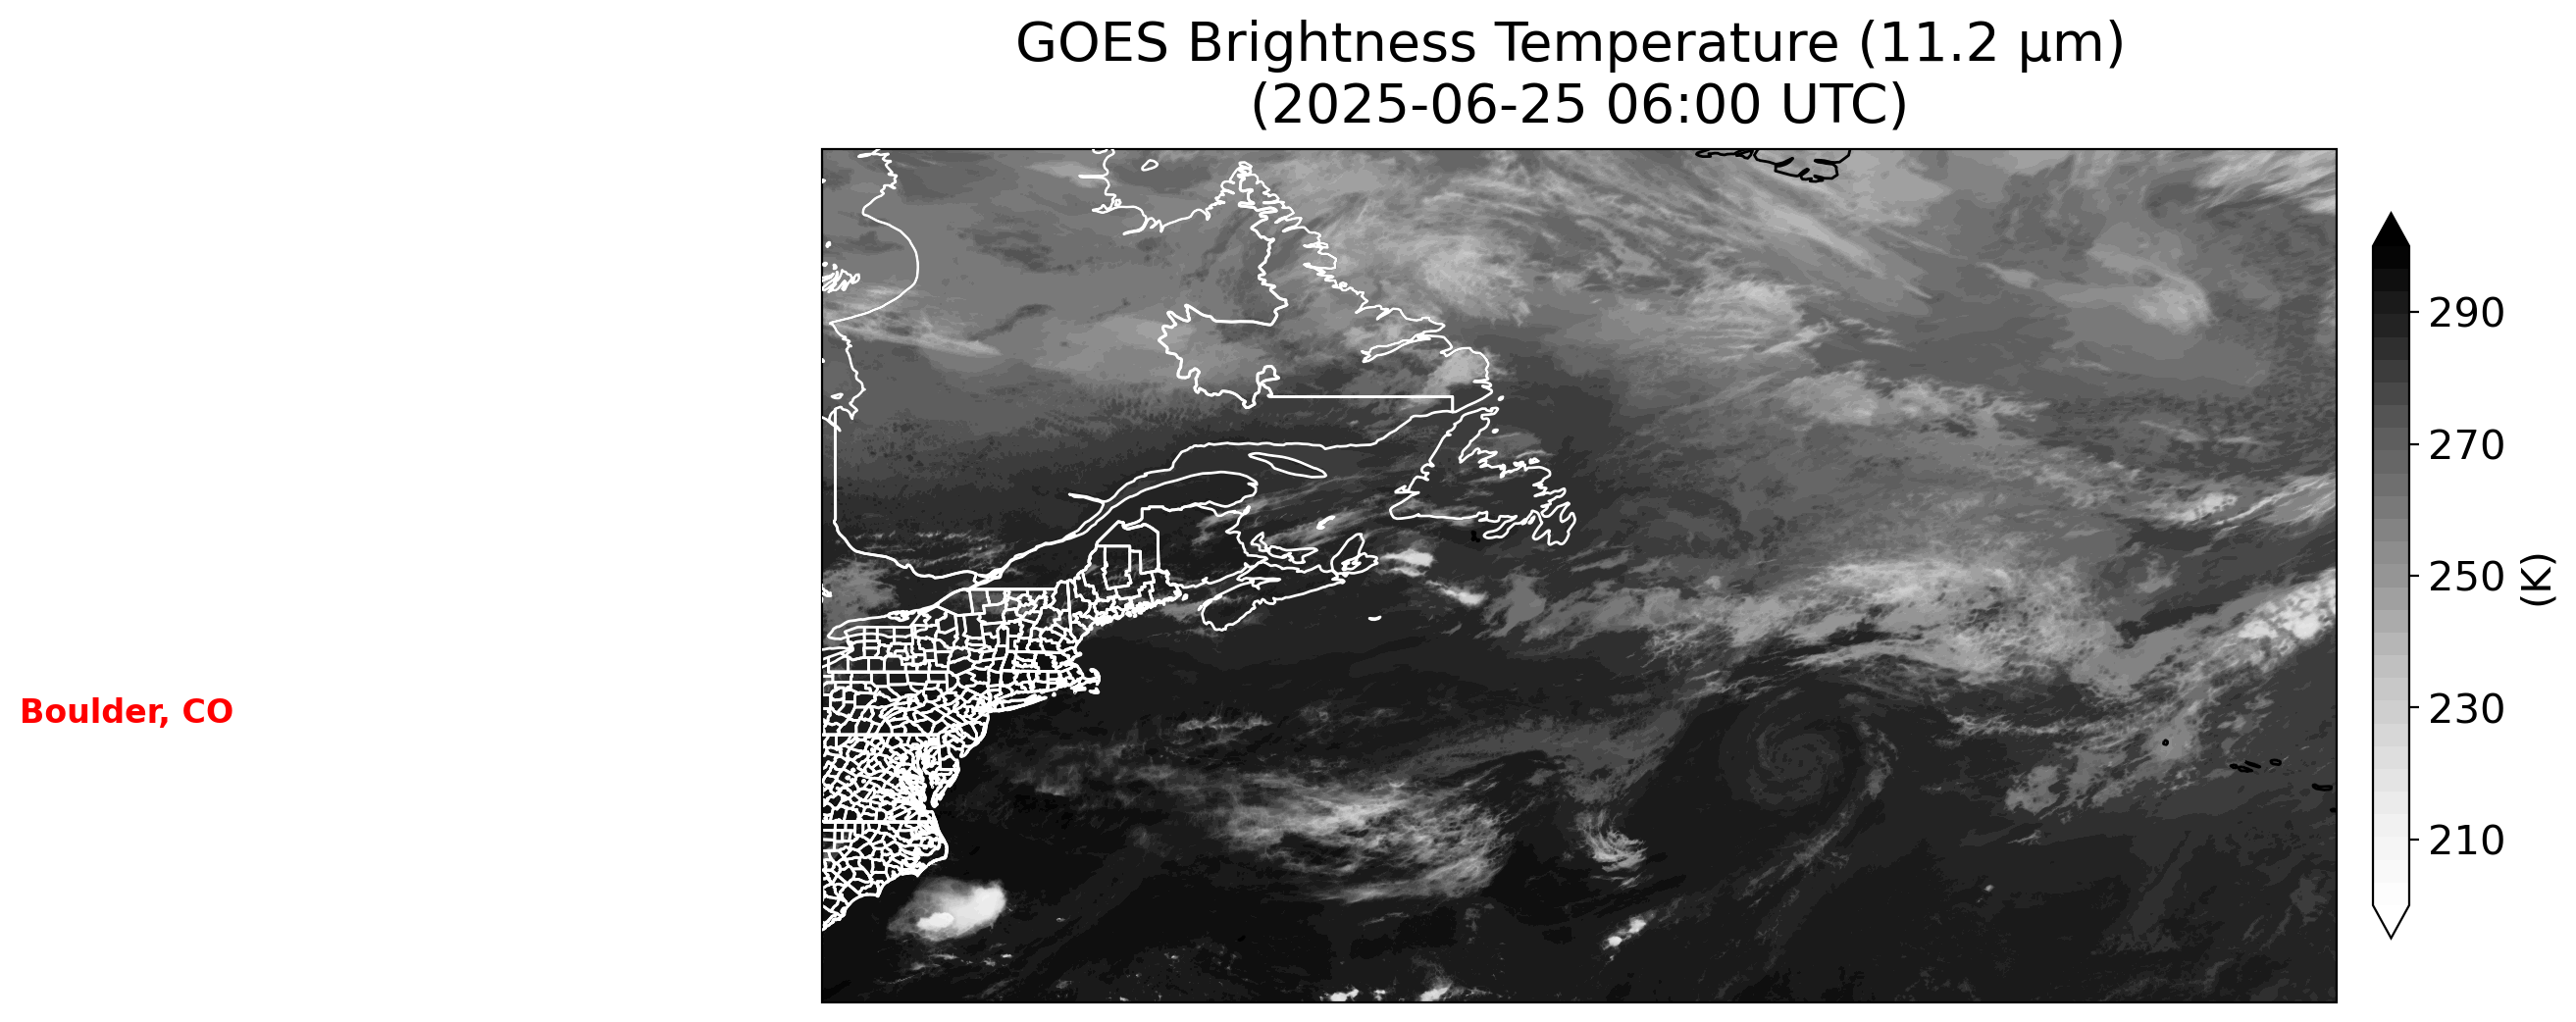

In [20]:
projection=ccrs.PlateCarree(central_longitude=0)

fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': projection})

levels = np.linspace(200, 300, 30)
c=ax.contourf(Tb.lon, Tb.lat, Tb, cmap='Greys', extend='both', levels=levels)


clb = plt.colorbar(c, shrink=0.4, pad=0.02, ax=ax)
clb.ax.tick_params(labelsize=15)
clb.set_label('(K)', fontsize=15)

custom_ticks = [290, 270, 250, 230, 210]
clb.set_ticks(custom_ticks)

#--- Remove for full-scan
ax.set_extent([longitude_west, longitude_east, latitude_south, latitude_north], crs=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

ax.set_title("GOES Brightness Temperature ("+ str(wl) +" μm) \n("+datetime_str[:-1]+":"+str(ten_minutes)+"0 UTC)", fontsize=20, pad=10)
ax.coastlines(resolution='50m', color='black', linewidth=1)
#ax.add_feature(feature.LAND, zorder=100, edgecolor='#000', facecolor='#DABC94')

#--- Lat and Lon lines
# gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', linestyle='--', zorder=5)
# gl.top_labels = False
# gl.right_labels = False
# ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.1f}°E' if x >= 0 else f'{-x:.1f}°W'))
# ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{y:.1f}°N' if y >= 0 else f'{-y:.1f}°S'))

#--- Counties
counties = feature.NaturalEarthFeature(
    category='cultural',
    name='admin_2_counties',
    scale='10m',
    facecolor='none')
ax.add_feature(counties, edgecolor='white', linewidth=1)

#--- States
ax.add_feature(feature.STATES, edgecolor='white', linewidth=1, zorder=6)

#--- Boulder CO bounding box
import matplotlib.patches as patches
boulder_bounds = {
    "latitude_north": 40.062,
    "latitude_south": 39.98,
    "longitude_west": -105.31,
    "longitude_east": -105.2
}
rect = patches.Rectangle(
    (boulder_bounds["longitude_west"], boulder_bounds["latitude_south"]),  # Bottom-left corner
    boulder_bounds["longitude_east"] - boulder_bounds["longitude_west"],  # Width
    boulder_bounds["latitude_north"] - boulder_bounds["latitude_south"],  # Height
    linewidth=2, edgecolor='red', facecolor='none', zorder=10
)
ax.add_patch(rect)
ax.text(
    (boulder_bounds["longitude_west"] + boulder_bounds["longitude_east"]) / 2,  # Center longitude
    boulder_bounds["latitude_north"] + 0.1,  # Slightly above the box
    "Boulder, CO",
    fontsize=12, color='red', fontweight='bold',
    horizontalalignment='center', transform=ccrs.PlateCarree()
)

fig.set_dpi(200)
fig.show()

**Create the strings for the save file:**

In [21]:
wl_str = str(wl).replace('.', '_')
date_str = str(datetime_str).replace('-', '_').replace(' ', '_')

**Get the brightness temperature difference:**
* Uses some of the variables defined above, does not run separately

In [22]:
band_1 = '14'
band_2 = '07'

In [23]:
files_band_1 = [file for file in files if fnmatch.fnmatch(file.split('/')[-1], 'OR_ABI-L1b-RadF-M6C' + band_1 + '*')]
file_1 = files_band_1[0]
files_band_2 = [file for file in files if fnmatch.fnmatch(file.split('/')[-1], 'OR_ABI-L1b-RadF-M6C' + band_2 + '*')]
file_2 = files_band_2[0]

In [24]:
resp_1 = requests.get(f'https://'+bucket+'.s3.amazonaws.com/'+file_1[12:])
if str(resp_1) != '<Response [200]>':
    print('band '+band_1+' file not found in AWS servers')

nc_1 = netCDF4.Dataset(file_1, memory = resp_1.content)
ds_1 = xr.open_dataset(xr.backends.NetCDF4DataStore(nc_1))

resp_2 = requests.get(f'https://'+bucket+'.s3.amazonaws.com/'+file_2[12:])
if str(resp_2) != '<Response [200]>':
    print('band '+band_2+' file not found in AWS servers')

nc_2 = netCDF4.Dataset(file_2, memory = resp_2.content)
ds_2 = xr.open_dataset(xr.backends.NetCDF4DataStore(nc_2))

In [25]:
ds_lat_lon_1 = calc_latlon(ds_1)
((x1,x2), (y1, y2)) = get_xy_from_latlon(ds_lat_lon_1, (latitude_south, latitude_north), (longitude_west, longitude_east))
region_1 = ds_lat_lon_1.sel(x=slice(x1, x2), y=slice(y2, y1))

ds_lat_lon_2 = calc_latlon(ds_2)
region_2 = ds_lat_lon_2.sel(x=slice(x1, x2), y=slice(y2, y1))

In [26]:
wl_1 = round(region_1.band_wavelength.values[0],1)
wl_2 = round(region_2.band_wavelength.values[0],1)

Tb_1 = (region_1.planck_fk2/(np.log((region_1.planck_fk1/region_1.Rad)+1)) - region_1.planck_bc1)/region_1.planck_bc2
Tb_2 = (region_2.planck_fk2/(np.log((region_2.planck_fk1/region_2.Rad)+1)) - region_2.planck_bc1)/region_2.planck_bc2

/var/folders/s0/p4kwg0r17s59t6f4g9btngzw0000gn/T/ipykernel_11860/1287789878.py:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


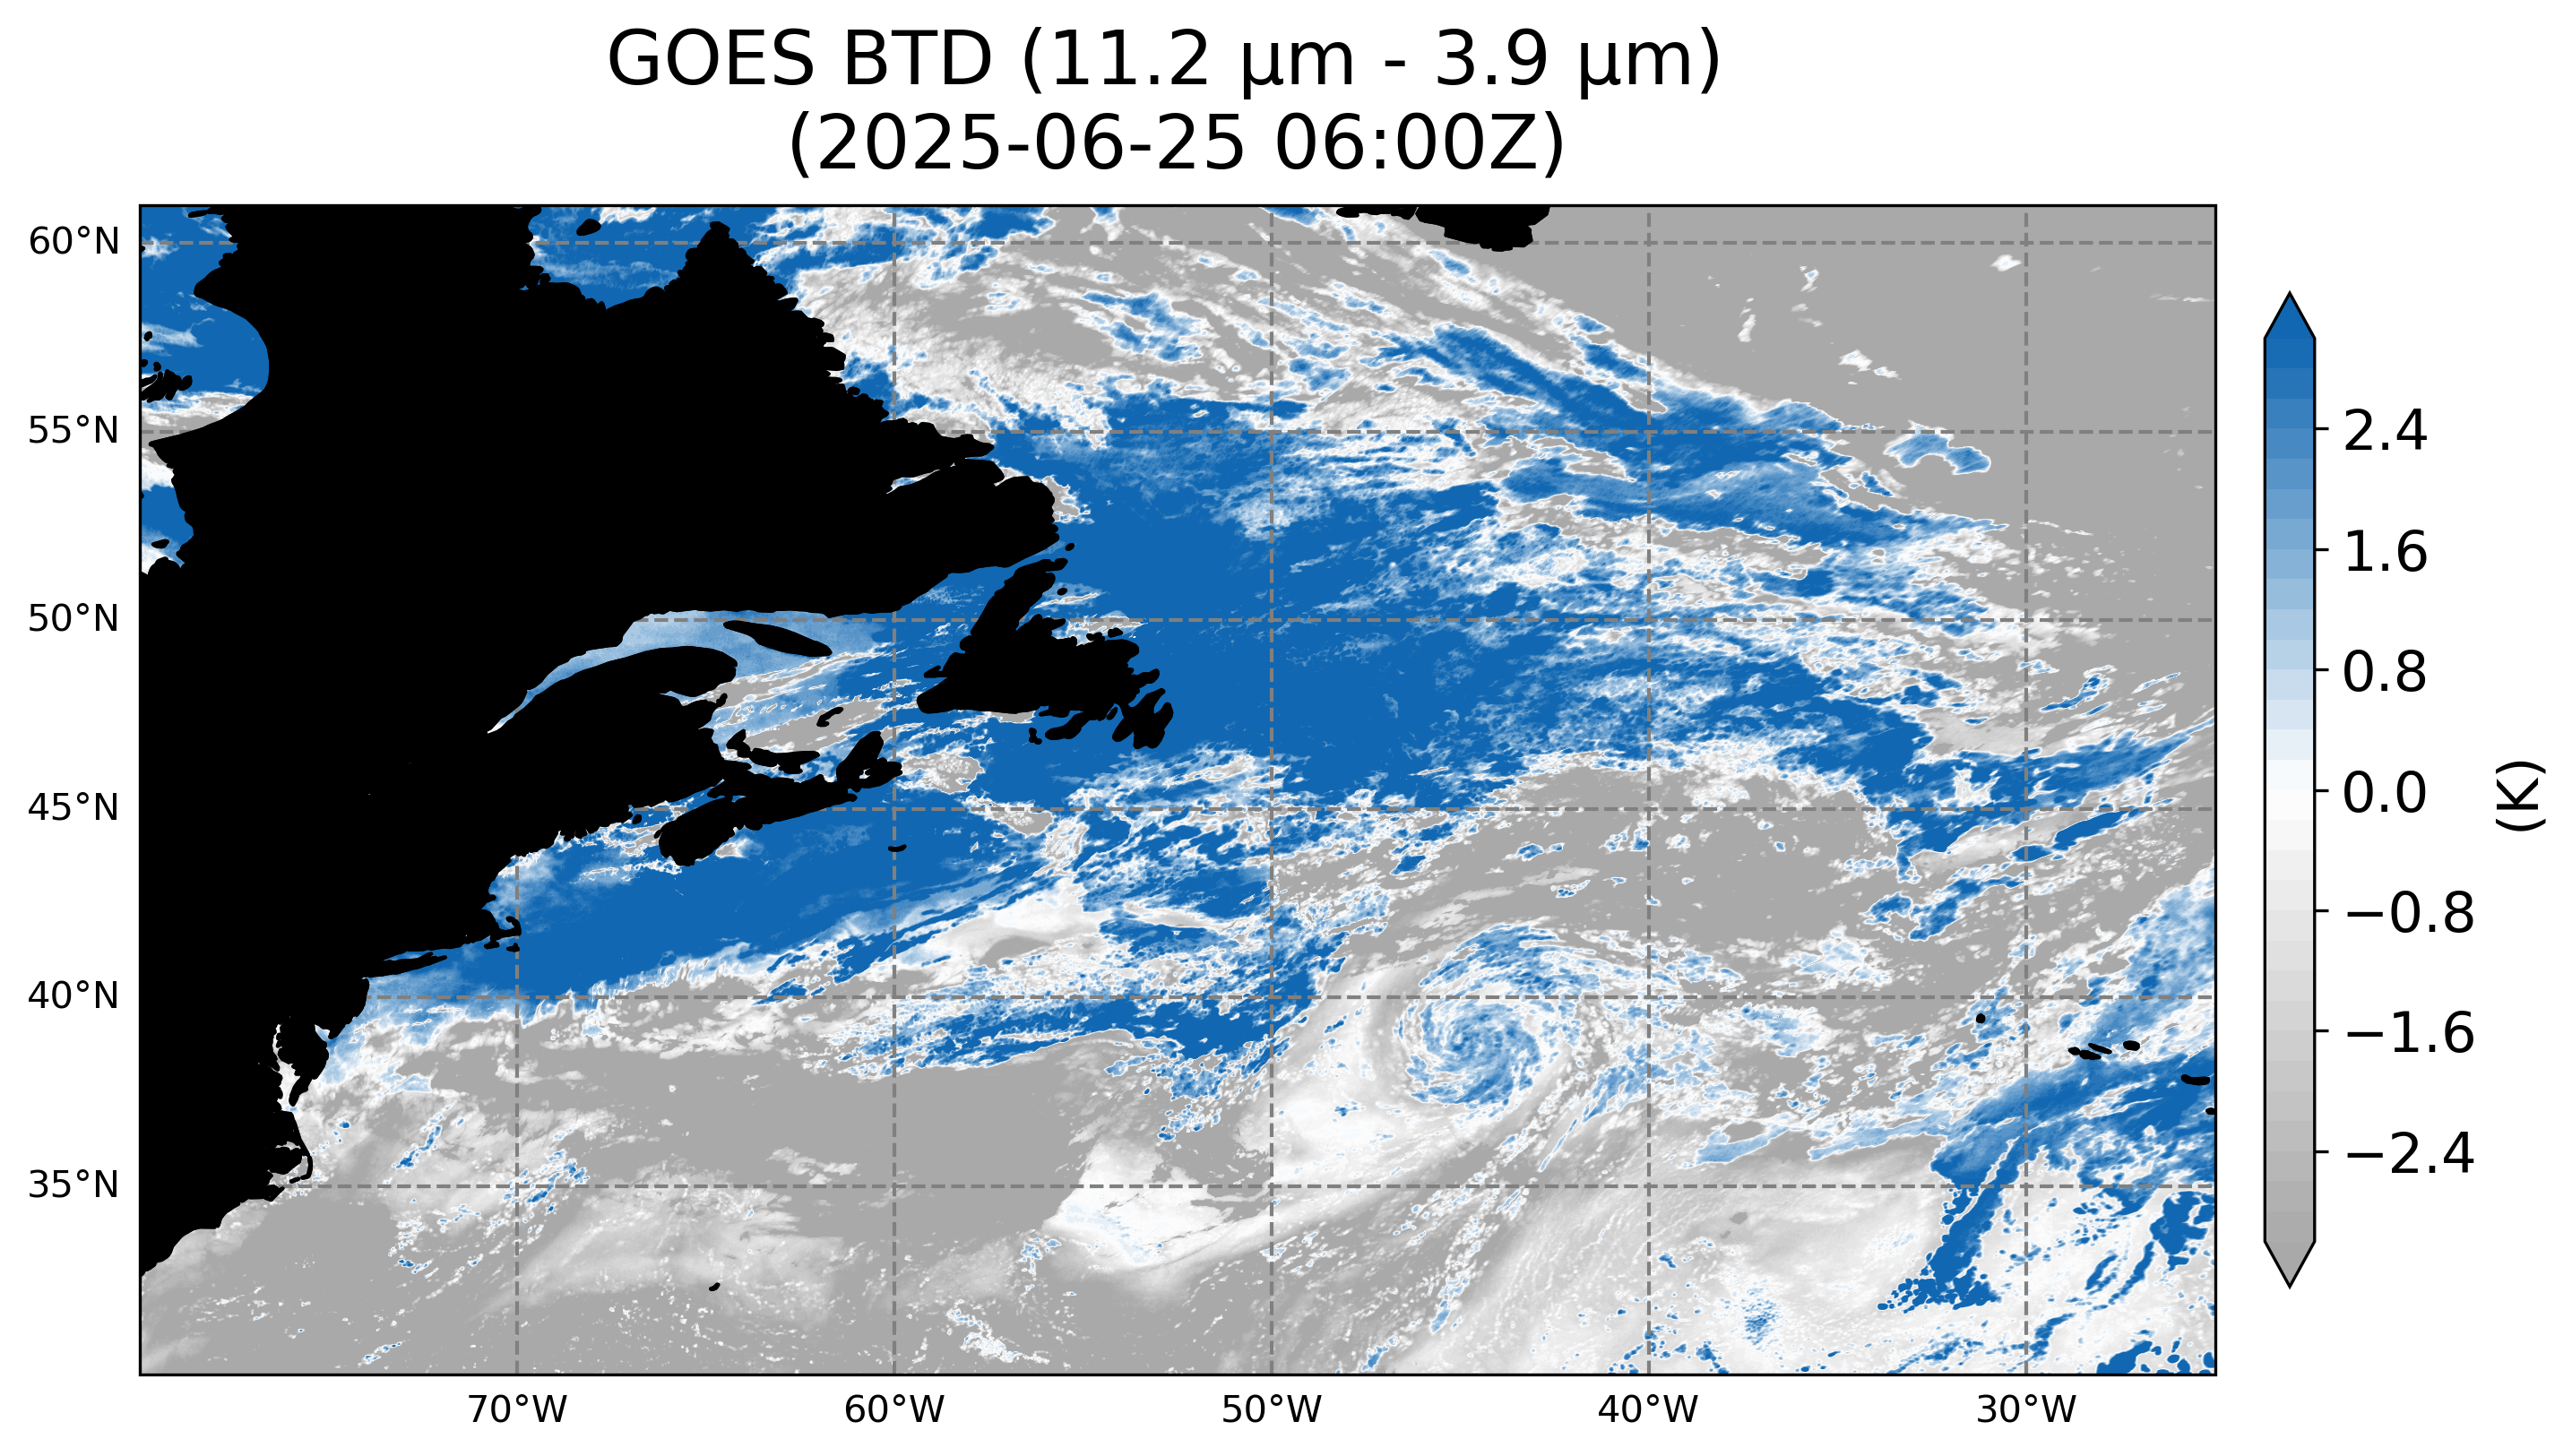

In [29]:
BTD = Tb_1 - Tb_2

projection=ccrs.PlateCarree(central_longitude=0)

fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': projection})

#---Custom colorbar
from matplotlib.colors import LinearSegmentedColormap
colors = [(0, '#A9A9A9'), (0.5, 'white'), (1, '#1167b1')]  # +3 = blueish teal, 0 = white, -3 = grey
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

#---Optional: Set large negative to another color to try to identify overriding cirrus
#cmap.set_under('#DABC94')

levels = np.linspace(-3, 3, 31)

c=ax.contourf(BTD.lon, BTD.lat, BTD, cmap=cmap, extend='both', levels=levels)


clb = plt.colorbar(c, shrink=0.4, pad=0.02, ax=ax)
clb.ax.tick_params(labelsize=15)
clb.set_label('(K)', fontsize=15)

#--- Remove for full-scan
ax.set_extent([longitude_west, longitude_east, latitude_south, latitude_north], crs=ccrs.PlateCarree())
#ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

ax.set_title("GOES BTD ("+ str(wl_1) +" μm - " + str(wl_2) +" μm) \n("+datetime_str[:-1]+":"+str(ten_minutes)+"0Z)", fontsize=20, pad=10)
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.add_feature(feature.LAND, zorder=100, edgecolor='#000', facecolor='#000')

#--- Lat and Lon lines
gl = ax.gridlines(draw_labels=True, linewidth=1, color='gray', linestyle='--', zorder=5)
gl.top_labels = False
gl.right_labels = False
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.1f}°E' if x >= 0 else f'{-x:.1f}°W'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{y:.1f}°N' if y >= 0 else f'{-y:.1f}°S'))

fig.set_dpi(300)
#fig.savefig("georgesbank_animation/satellite_btd_"+date_str, dpi=200, bbox_inches='tight')
fig.show()

In [ ]:
#--- Save BTD at netCDF
#BTD.to_netcdf(f"FLCI_scatter_plot_data/satellite_{date_str}.nc")

/Applications/anaconda3/envs/FLC_Workspace_3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3667: SerializationWarning: saving variable y with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)
/Applications/anaconda3/envs/FLC_Workspace_3/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3667: SerializationWarning: saving variable x with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)


In [23]:
#--- BTD value at the point by YQI
target_lat = 43.8
target_lon = -66.2

# Compute absolute difference between all grid points and the target
abs_diff = np.abs(BTD['lat'] - target_lat) + np.abs(BTD['lon'] - target_lon)

# Find the indices of the minimum difference
min_idx = np.unravel_index(abs_diff.argmin().values, abs_diff.shape)

# Extract x and y index
y_idx, x_idx = min_idx  # xarray uses (y, x) ordering in shape

# Select the value from BTD
point = BTD.isel(x=x_idx, y=y_idx)

matched_lat = BTD['lat'].isel(x=x_idx, y=y_idx).values
matched_lon = BTD['lon'].isel(x=x_idx, y=y_idx).values
print(f"Matched to lat={matched_lat:.3f}, lon={matched_lon:.3f}")

print(f"BTD at closest point to YQI: {point.values}")

Matched to lat=43.813, lon=-66.202
BTD at closest point to YQI: 3.56787109375


**Geostationary projection:**
* Used pcolormesh because it is much faster than contourf
* Considering replacing it in the PlateCarree run as well

/var/folders/pd/x01_y6d52zj47w6_m5_h_8f80000gr/T/ipykernel_71702/3313409958.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


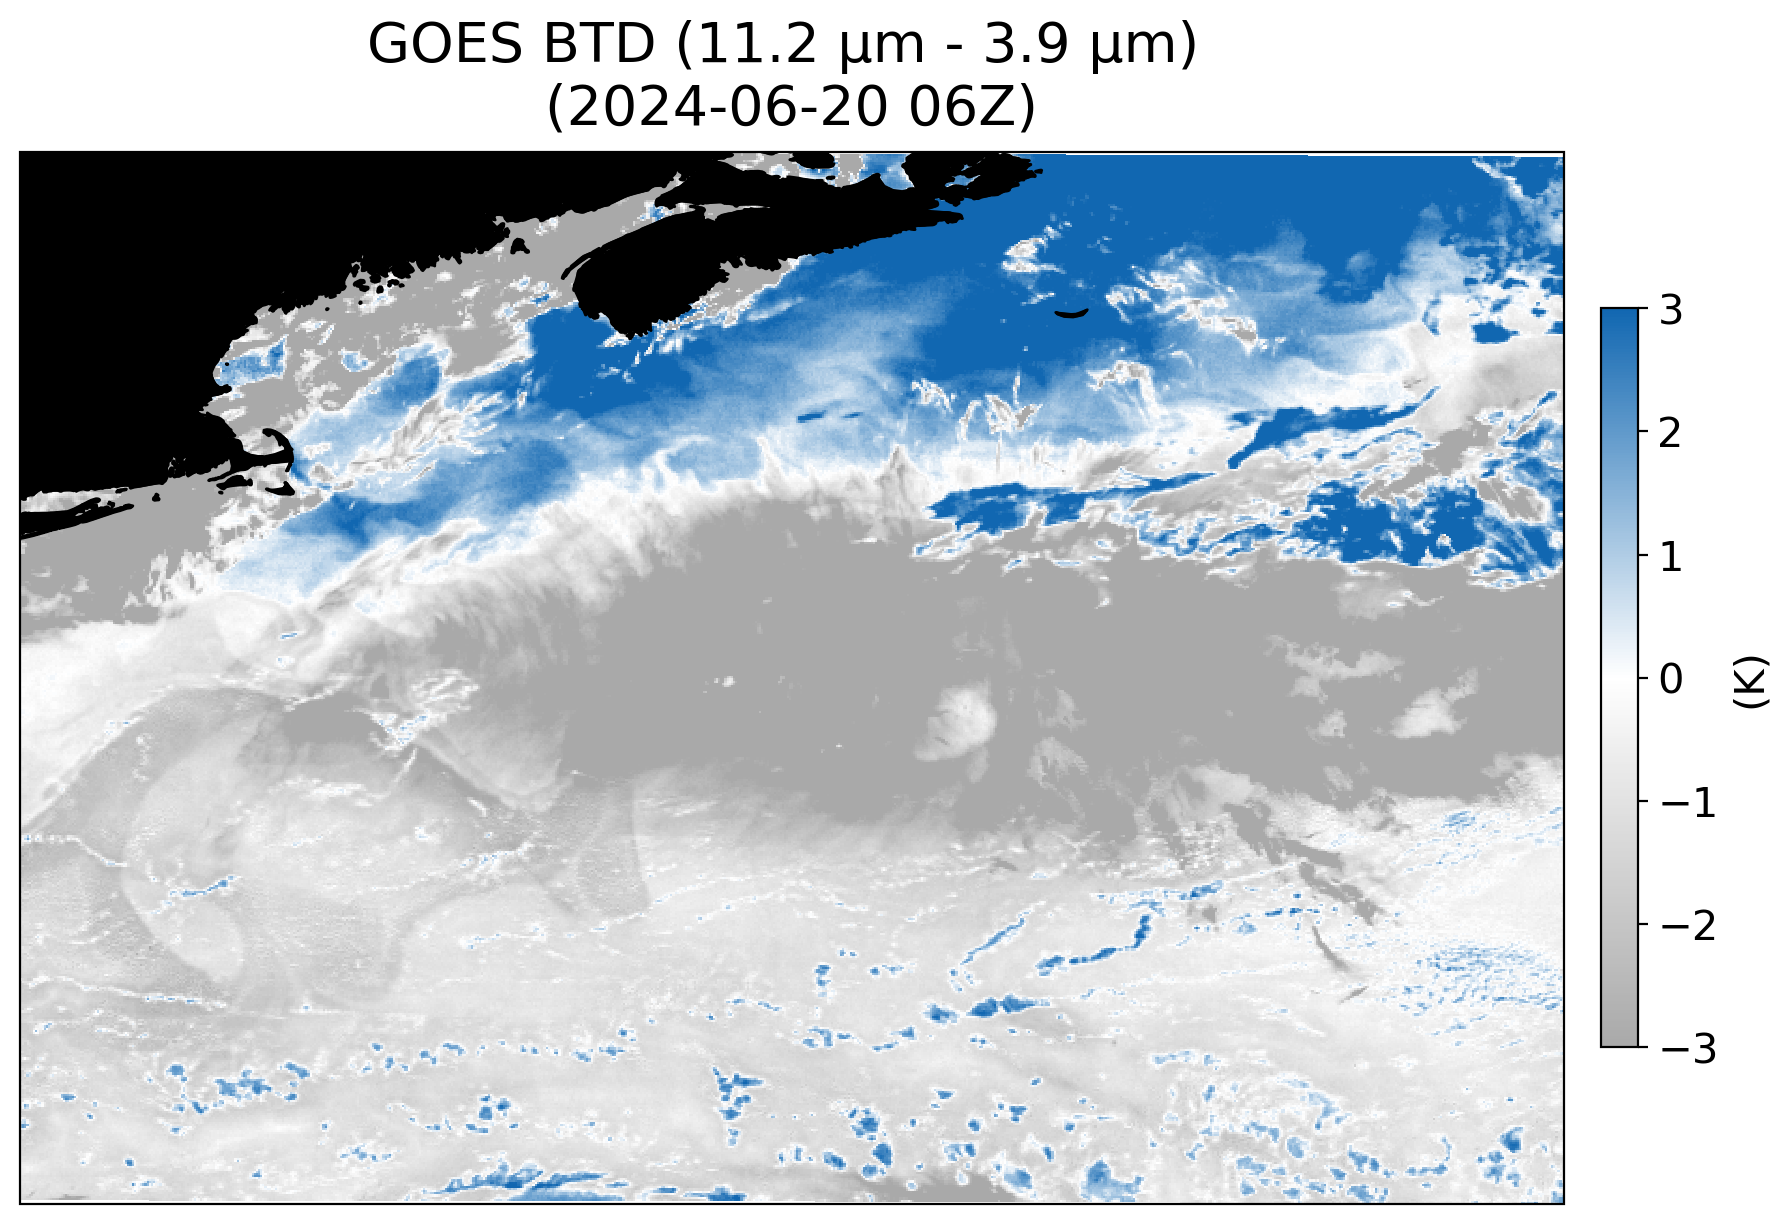

In [24]:
BTD = Tb_1 - Tb_2

# --- Orthographic projection for GOES-E
projection = ccrs.Geostationary(central_longitude=-75, satellite_height=35785831, false_easting=0, false_northing=0, globe=None, sweep_axis='y')

fig, ax = plt.subplots(1, figsize=(12, 12), subplot_kw={'projection': projection})

# --- Custom colorbar
from matplotlib.colors import LinearSegmentedColormap
colors = [(0, '#A9A9A9'), (0.5, 'white'), (1, '#1167b1')]  # +3 = blueish teal, 0 = white, -3 = grey
cmap = LinearSegmentedColormap.from_list('custom_cmap', colors)

# Use pcolormesh instead of contourf
mesh = ax.pcolormesh(BTD.lon, BTD.lat, BTD, cmap=cmap, vmin=-3, vmax=3, transform=ccrs.PlateCarree())

# Colorbar
clb = plt.colorbar(mesh, shrink=0.4, pad=0.02, ax=ax)
clb.ax.tick_params(labelsize=15)
clb.set_label('(K)', fontsize=15)

#--- Limited extent (if not full-scan)
ax.set_extent([longitude_west, longitude_east, latitude_south, latitude_north], crs=ccrs.PlateCarree())

ax.set_title("GOES BTD (" + str(wl_1) + " μm - " + str(wl_2) + " μm) \n(" + datetime_str + ")", fontsize=20, pad=10)
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.add_feature(feature.LAND, zorder=100, edgecolor='#000', facecolor='#000')

fig.set_dpi(200)
# fig.savefig("/Users/jesseturner/Downloads/satellite_btd_" + date_str, dpi=200, bbox_inches='tight')
fig.show()